<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/05_MNIST_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio E

## MNIST con TensorFlow + Keras, sin CNN

**Objetivo:** reconocer dígitos escritos a mano (0-9) usando una red densa **784 → 128 → 10**. La actividad prohíbe redes convolucionales, por lo que se utiliza `Flatten` + `Dense`.

In [2]:

# ============================================
# LABORATORIO E - MNIST CON TENSORFLOW + KERAS
# ============================================
# MNIST contiene imágenes de dígitos escritos a mano.
# Cada imagen tiene 28x28 píxeles.
#
# IMPORTANTE:
# No utilizamos redes convolucionales (CNN).
# Usaremos Flatten + Dense.

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)


In [3]:
# ============================================
# CARGAR MNIST
# ============================================
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = (
    keras.datasets.mnist.load_data()
)

print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba       :", x_test_mnist.shape, y_test_mnist.shape)


Entrenamiento: (60000, 28, 28) (60000,)
Prueba       : (10000, 28, 28) (10000,)


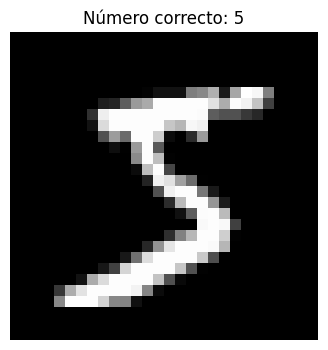

In [4]:
# ============================================
# VISUALIZAR UNA IMAGEN
# ============================================
plt.figure(figsize=(4, 4))
plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

In [5]:
# ============================================
# NORMALIZAR LOS PÍXELES
# ============================================
# Los píxeles originales están entre 0 y 255.
# Los llevamos al intervalo 0 a 1.

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())

Mínimo: 0.0
Máximo: 1.0


In [6]:
# ============================================
# ARQUITECTURA 784 -> 128 -> 10
# ============================================
# Flatten transforma 28x28 = 784 valores.
# La última capa tiene 10 neuronas: una para cada dígito.

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo_mnist.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================
# COMPILAR
# ============================================
modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# ============================================
# ENTRENAR
# ============================================
historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9230 - loss: 0.2693 - val_accuracy: 0.9617 - val_loss: 0.1291
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9641 - loss: 0.1195 - val_accuracy: 0.9682 - val_loss: 0.1043
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9756 - loss: 0.0826 - val_accuracy: 0.9690 - val_loss: 0.0971
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9822 - loss: 0.0612 - val_accuracy: 0.9700 - val_loss: 0.0936
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0458 - val_accuracy: 0.9732 - val_loss: 0.0898


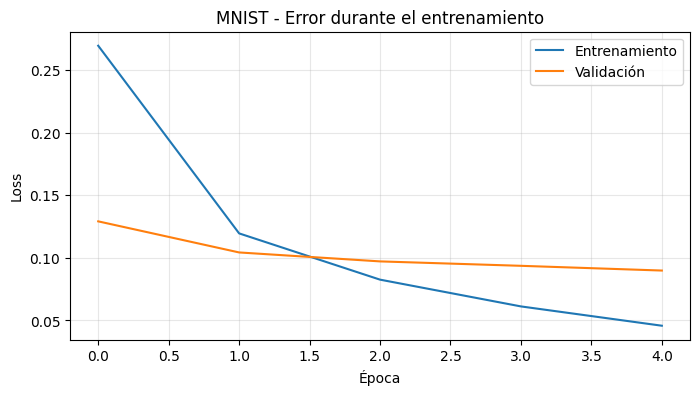

In [9]:
# ============================================
# GRAFICAR LOSS
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("MNIST - Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

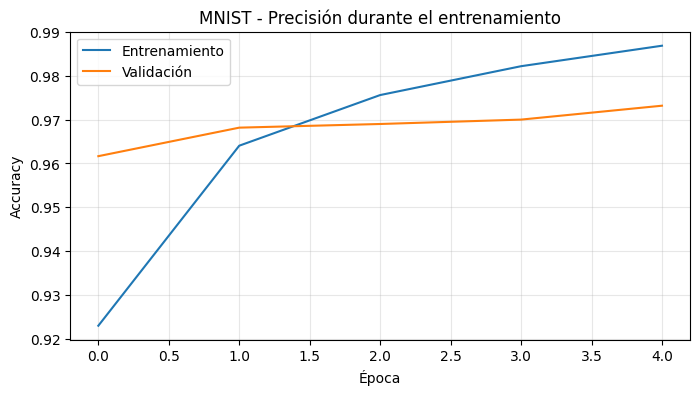

In [10]:
# ============================================
# GRAFICAR ACCURACY
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("MNIST - Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ============================================
# EVALUAR EL MODELO
# ============================================
test_loss_mnist, test_accuracy_mnist = modelo_mnist.evaluate(
    x_test_mnist,
    y_test_mnist,
    verbose=0
)

print("Loss de prueba:", test_loss_mnist)
print("Accuracy de prueba:", test_accuracy_mnist)

Loss de prueba: 0.09653592854738235
Accuracy de prueba: 0.9699000120162964


In [12]:
# ============================================
# PRIMERAS 10 PREDICCIONES
# ============================================
predicciones_mnist = modelo_mnist.predict(
    x_test_mnist[:10],
    verbose=0
)

for i in range(10):
    prediccion = np.argmax(predicciones_mnist[i])
    print(
        f"Imagen {i+1} | "
        f"Real: {y_test_mnist[i]} | "
        f"Predicción: {prediccion}"
    )

Imagen 1 | Real: 7 | Predicción: 7
Imagen 2 | Real: 2 | Predicción: 2
Imagen 3 | Real: 1 | Predicción: 1
Imagen 4 | Real: 0 | Predicción: 0
Imagen 5 | Real: 4 | Predicción: 4
Imagen 6 | Real: 1 | Predicción: 1
Imagen 7 | Real: 4 | Predicción: 4
Imagen 8 | Real: 9 | Predicción: 9
Imagen 9 | Real: 5 | Predicción: 6
Imagen 10 | Real: 9 | Predicción: 9


Cantidad de errores: 301


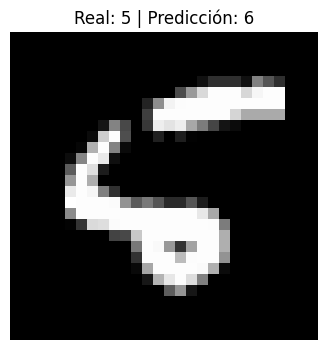

In [13]:
# ============================================
# BUSCAR UN ERROR DEL MODELO
# ============================================
predicciones_todas = modelo_mnist.predict(
    x_test_mnist,
    verbose=0
)

clases_predichas = np.argmax(
    predicciones_todas,
    axis=1
)

errores = np.where(
    clases_predichas != y_test_mnist
)[0]

print("Cantidad de errores:", len(errores))

if len(errores) > 0:
    indice_error = errores[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(x_test_mnist[indice_error], cmap="gray")
    plt.title(
        f"Real: {y_test_mnist[indice_error]} | "
        f"Predicción: {clases_predichas[indice_error]}"
    )
    plt.axis("off")
    plt.show()